In [3]:
# Install and Import Necessary libraries
from pathlib import Path
import random
import sys
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

warnings.filterwarnings("ignore")

# A fixed seed makes the experiment reproducible.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Python version:", sys.version)
print("Pandas version:", pd.__version__)
print("Scikit-learn version:", sklearn.__version__)

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Pandas version: 2.2.2
Scikit-learn version: 1.6.1


In [4]:
# Load the dataset


df = pd.read_csv("/content/Crop_recommendation.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
# Validate the dataset structure
expected_columns = [
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall",
    "label"
]

missing_columns = set(expected_columns) - set(df.columns)
unexpected_columns = set(df.columns) - set(expected_columns)

if missing_columns:
    raise ValueError(f"Required columns are missing: {missing_columns}")

if unexpected_columns:
    print(f"Warning: unexpected columns detected: {unexpected_columns}")

# Retain the columns in a consistent order.
df = df[expected_columns].copy()

print("Columns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Data types:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object


In [6]:
# Initial Data Quality check
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nMissing values:")
print(df.isna().sum())

print("\nNumber of duplicated rows:")
print(df.duplicated().sum())

print("\nNumber of crop classes:")
print(df["label"].nunique())

print("\nObservations per crop:")
print(df["label"].value_counts().sort_index())

Number of rows: 2200
Number of columns: 8

Missing values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Number of duplicated rows:
0

Number of crop classes:
22

Observations per crop:
label
apple          100
banana         100
blackgram      100
chickpea       100
coconut        100
coffee         100
cotton         100
grapes         100
jute           100
kidneybeans    100
lentil         100
maize          100
mango          100
mothbeans      100
mungbean       100
muskmelon      100
orange         100
papaya         100
pigeonpeas     100
pomegranate    100
rice           100
watermelon     100
Name: count, dtype: int64


In [7]:
# Removing duplicates
df = df.drop_duplicates().reset_index(drop=True)

# The dataset currently has no missing values.
# Median imputation is shown as a defensive procedure
feature_columns = [
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall"
]

for column in feature_columns:
    if df[column].isna().any():
        df[column] = df[column].fillna(df[column].median())

# Remove observations with missing target labels
df = df.dropna(subset=["label"]).reset_index(drop=True)

print("Final shape after quality checks:", df.shape)
print("Remaining missing values:", df.isna().sum().sum())

Final shape after quality checks: (2200, 8)
Remaining missing values: 0


In [8]:
# Descriptive statistics
descriptive_statistics = df[feature_columns].describe().T

descriptive_statistics["range"] = (
    descriptive_statistics["max"] - descriptive_statistics["min"]
)

descriptive_statistics.round(3)

,count,mean,std,min,25%,50%,75%,max,range
N,2200.0,50.552,36.917,0.000,21.000,37.000,84.250,140.000,140.000
P,2200.0,53.363,32.986,5.000,28.000,51.000,68.000,145.000,140.000
K,2200.0,48.149,50.648,5.000,20.000,32.000,49.000,205.000,200.000
temperature,2200.0,25.616,5.064,8.826,22.769,25.599,28.562,43.675,34.850
humidity,2200.0,71.482,22.264,14.258,60.262,80.473,89.949,99.982,85.724
ph,2200.0,6.469,0.774,3.505,5.972,6.425,6.924,9.935,6.430
rainfall,2200.0,103.464,54.958,20.211,64.552,94.868,124.268,298.560,278.349


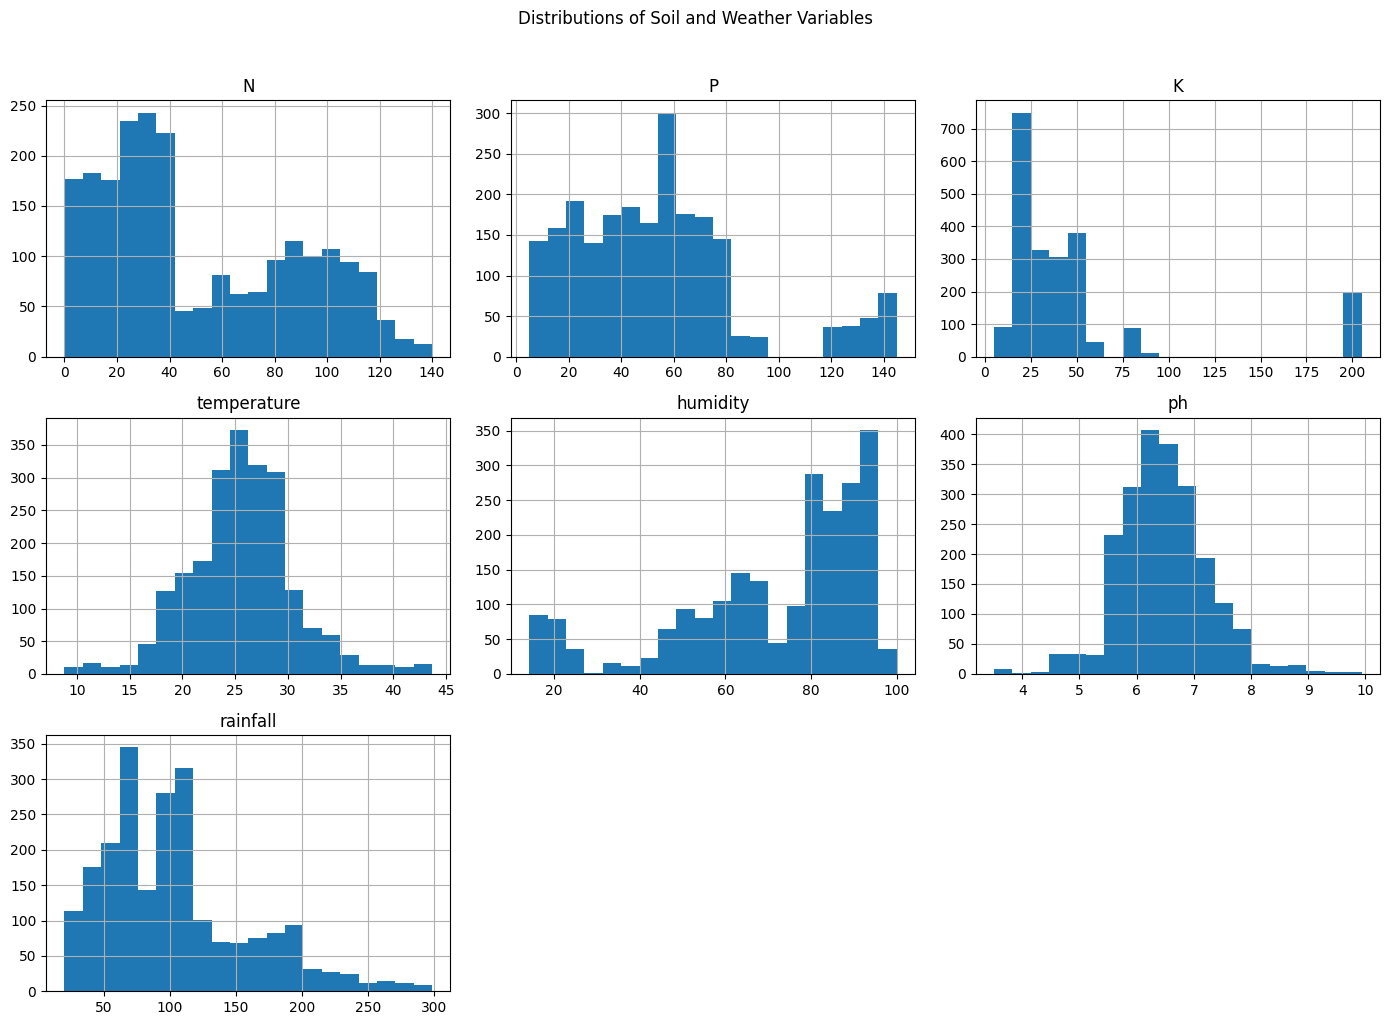

In [9]:
# Examine numerical feature distributions
df[feature_columns].hist(
    bins=20,
    figsize=(14, 10)
)

plt.suptitle("Distributions of Soil and Weather Variables", y=1.02)
plt.tight_layout()
plt.show()

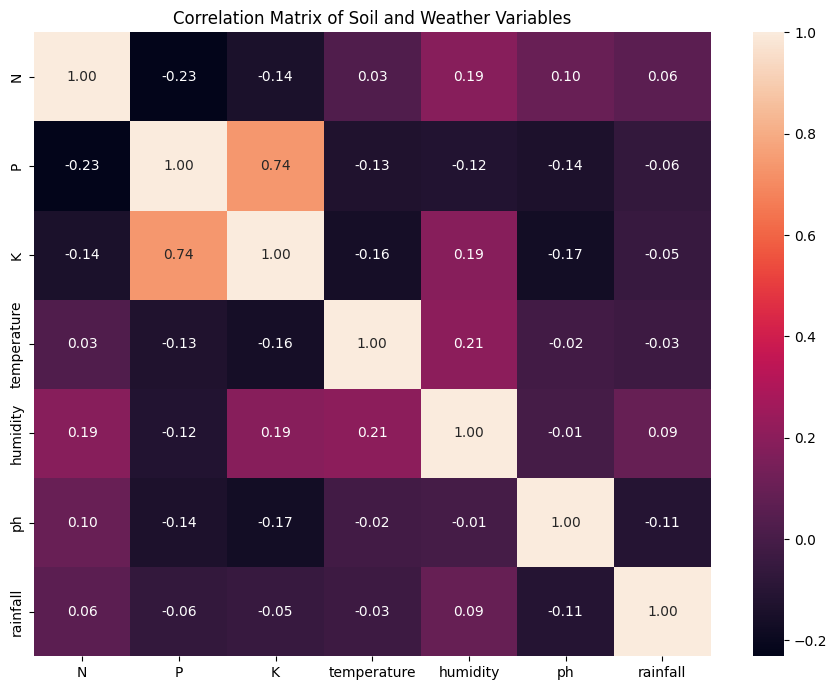

In [10]:
# Examine relationships between numerical variables
correlation_matrix = df[feature_columns].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix of Soil and Weather Variables")
plt.tight_layout()
plt.show()

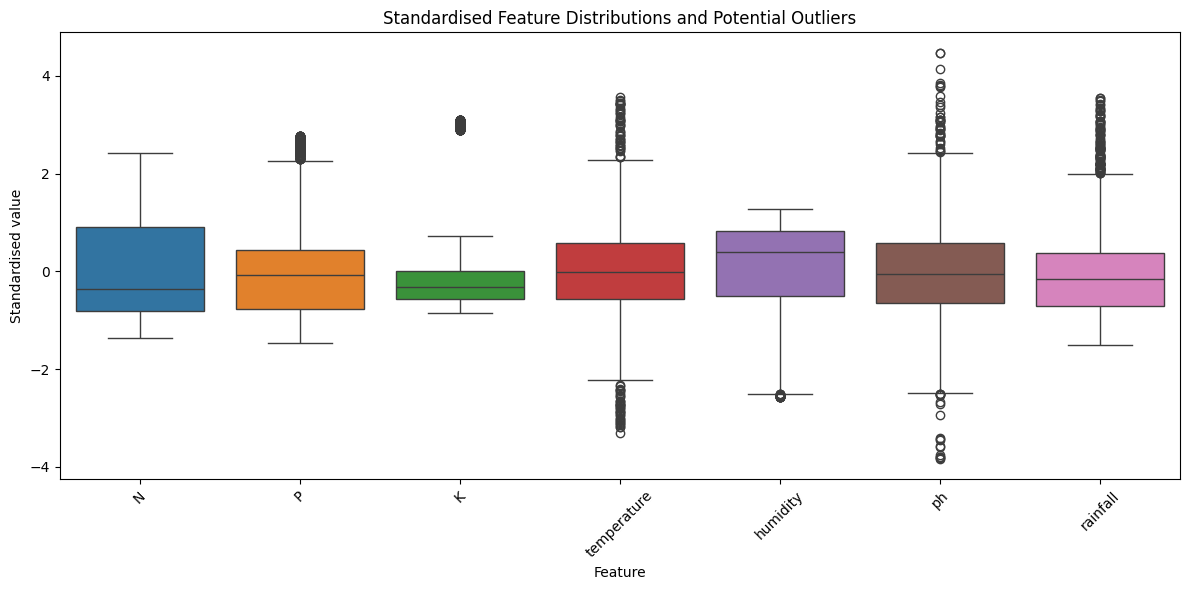

In [11]:
# Investigate possible outliers
standardised_features = (
    df[feature_columns] - df[feature_columns].mean()
) / df[feature_columns].std()

plt.figure(figsize=(12, 6))
sns.boxplot(data=standardised_features)

plt.title("Standardised Feature Distributions and Potential Outliers")
plt.xlabel("Feature")
plt.ylabel("Standardised value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
outlier_summary = {}

for column in feature_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower_boundary = q1 - 1.5 * iqr
    upper_boundary = q3 + 1.5 * iqr

    outliers = (
        (df[column] < lower_boundary) |
        (df[column] > upper_boundary)
    )

    outlier_summary[column] = {
        "Lower boundary": lower_boundary,
        "Upper boundary": upper_boundary,
        "Potential outliers": int(outliers.sum())
    }

outlier_table = pd.DataFrame(outlier_summary).T
outlier_table.round(3)

,Lower boundary,Upper boundary,Potential outliers
N,-73.875,179.125,0.0
P,-32.000,128.000,138.0
K,-23.500,92.500,200.0
temperature,14.081,37.250,86.0
humidity,15.732,134.479,30.0
ph,4.544,8.352,57.0
rainfall,-25.022,213.841,100.0


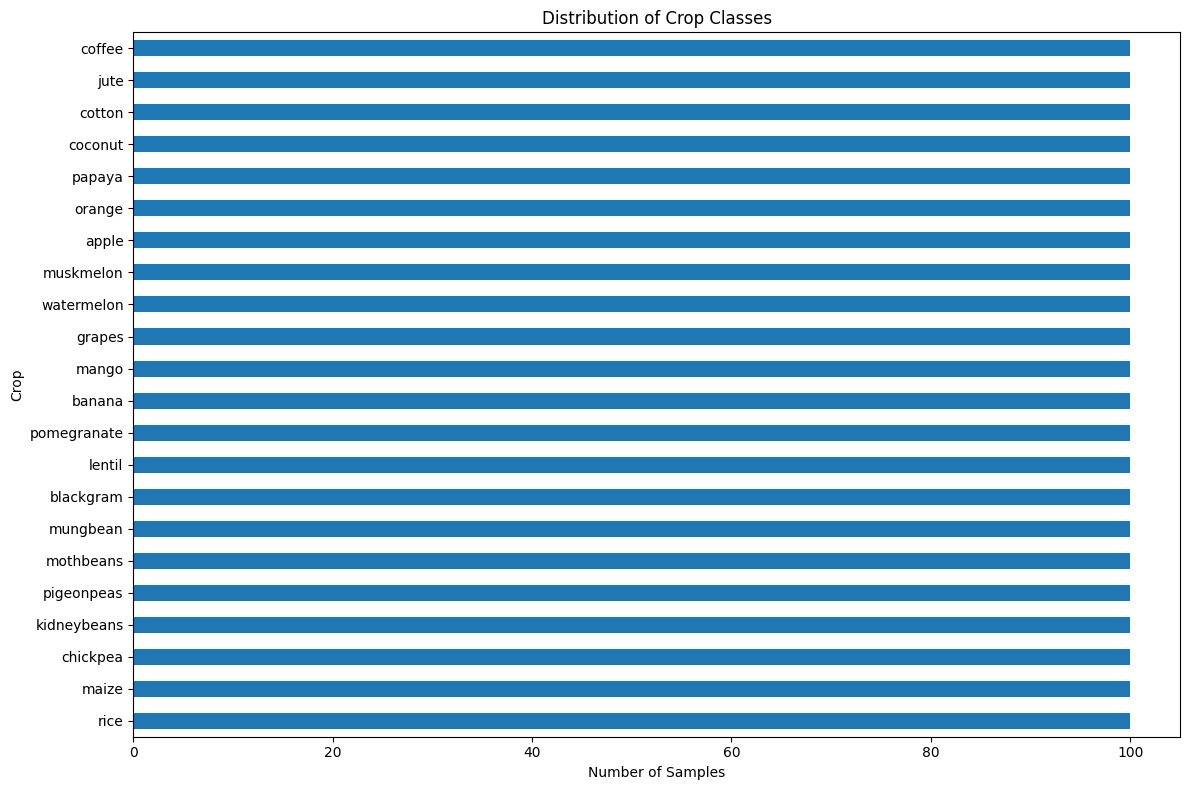

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


In [13]:
# Crop Class Distribution

crop_counts = df["label"].value_counts().sort_values()

plt.figure(figsize=(12,8))

crop_counts.plot(kind="barh")

plt.title("Distribution of Crop Classes")
plt.xlabel("Number of Samples")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

print(crop_counts)

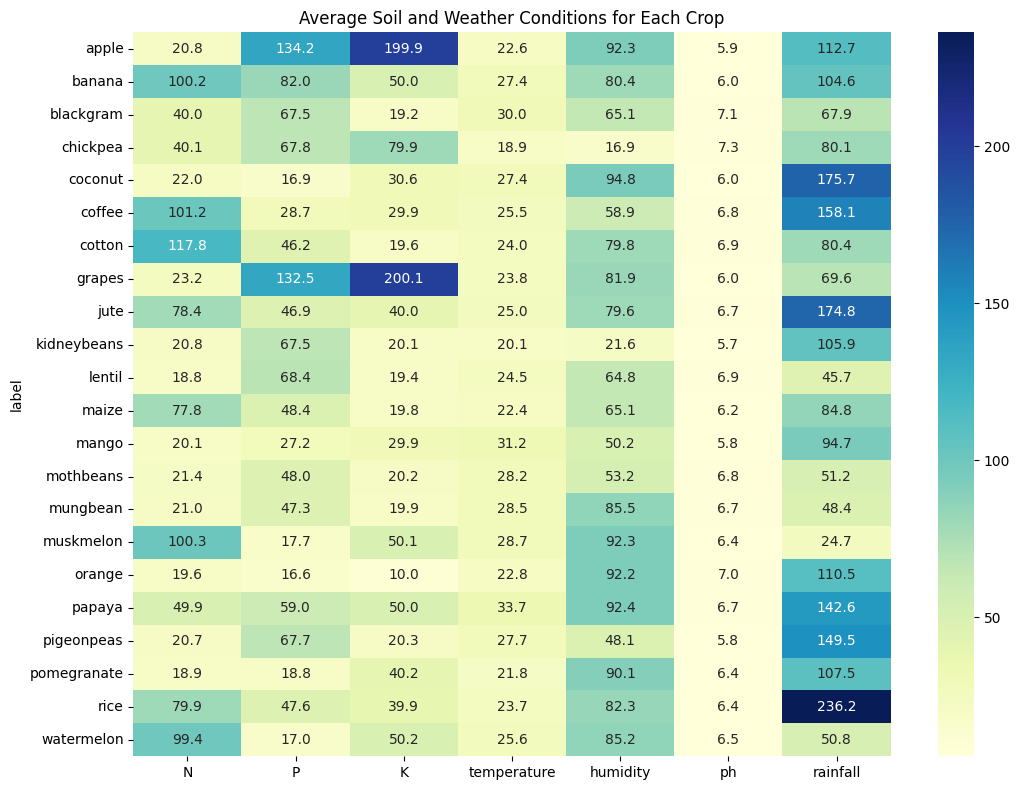

In [14]:
# Average Feature Values per Crop
crop_mean = df.groupby("label")[feature_columns].mean()

plt.figure(figsize=(11,8))

sns.heatmap(
    crop_mean,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Average Soil and Weather Conditions for Each Crop")

plt.tight_layout()

plt.show()

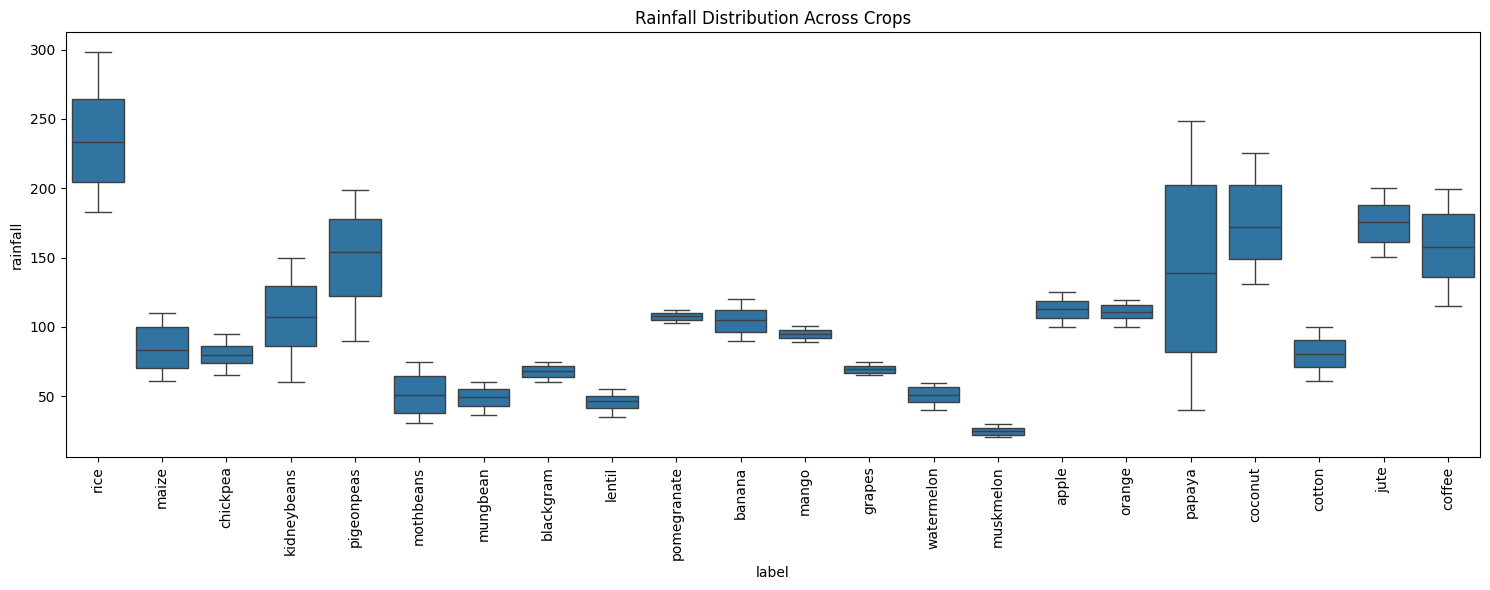

In [15]:
# Rainfall Distribution

plt.figure(figsize=(15,6))

sns.boxplot(
    data=df,
    x="label",
    y="rainfall"
)

plt.xticks(rotation=90)

plt.title("Rainfall Distribution Across Crops")

plt.tight_layout()

plt.show()

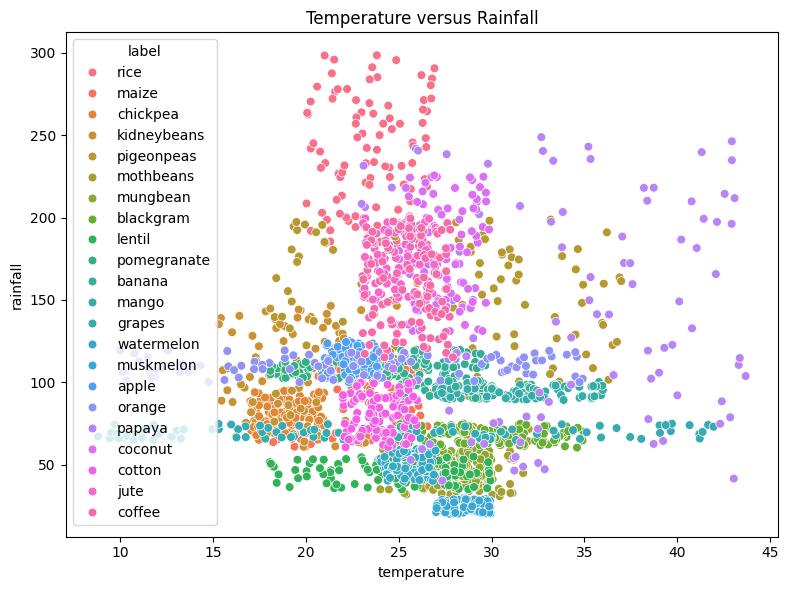

In [16]:
# Temperature vs Rainfall
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="temperature",
    y="rainfall",
    hue="label",
    s=40
)

plt.title("Temperature versus Rainfall")

plt.tight_layout()

plt.show()

In [17]:
# Encode Crop Labels

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["label_encoded"] = encoder.fit_transform(df["label"])

corr_target = df.corr(numeric_only=True)["label_encoded"]

print(corr_target)

N               -0.031130
P               -0.491006
K               -0.346417
temperature      0.113606
humidity         0.193911
ph              -0.012253
rainfall         0.045611
label_encoded    1.000000
Name: label_encoded, dtype: float64


In [18]:
# Skewness

skewness = df[feature_columns].skew()

print(skewness.sort_values())

humidity      -1.091708
temperature    0.184933
ph             0.283929
N              0.509721
rainfall       0.965756
P              1.010773
K              2.375167
dtype: float64


In [19]:
# Kurtosis

kurtosis = df[feature_columns].kurtosis()

print(kurtosis.sort_values())

N             -1.058240
humidity       0.302134
rainfall       0.607079
P              0.860279
temperature    1.232555
ph             1.655581
K              4.449354
dtype: float64


In [20]:
# Variability of Features

cv = (
    df[feature_columns].std() /
    df[feature_columns].mean()
) * 100

cv = cv.sort_values(ascending=False)

print(cv)

K              105.189796
N               73.028696
P               61.814462
rainfall        53.118545
humidity        31.146135
temperature     19.767725
ph              11.962904
dtype: float64


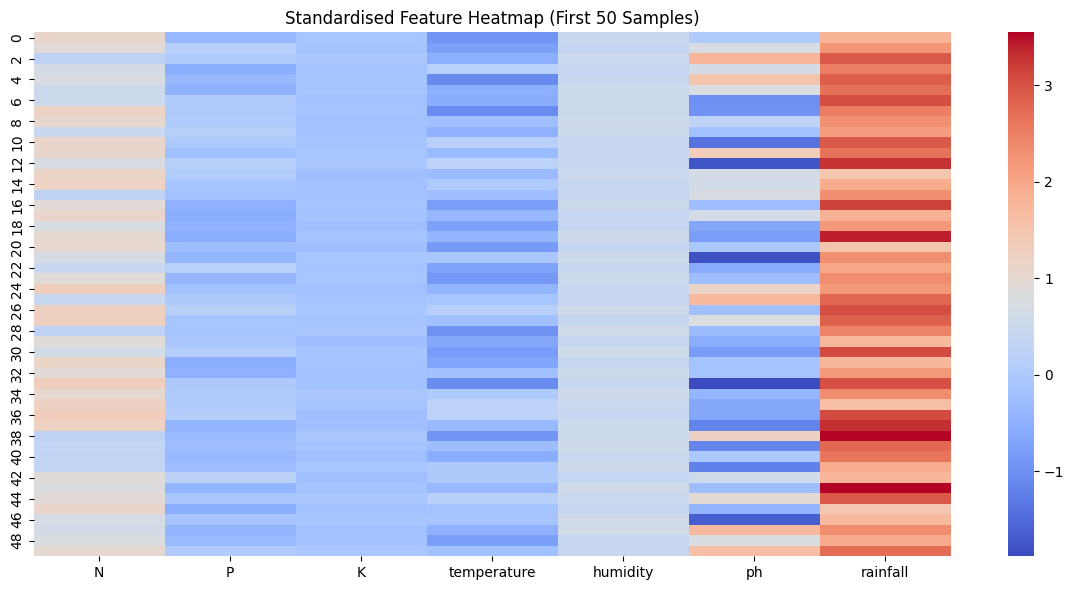

In [21]:
# Standardised Feature Heatmap

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(df[feature_columns])

scaled_df = pd.DataFrame(
    scaled,
    columns=feature_columns
)

plt.figure(figsize=(12,6))

sns.heatmap(
    scaled_df.iloc[:50],
    cmap="coolwarm",
    cbar=True
)

plt.title("Standardised Feature Heatmap (First 50 Samples)")

plt.tight_layout()

plt.show()

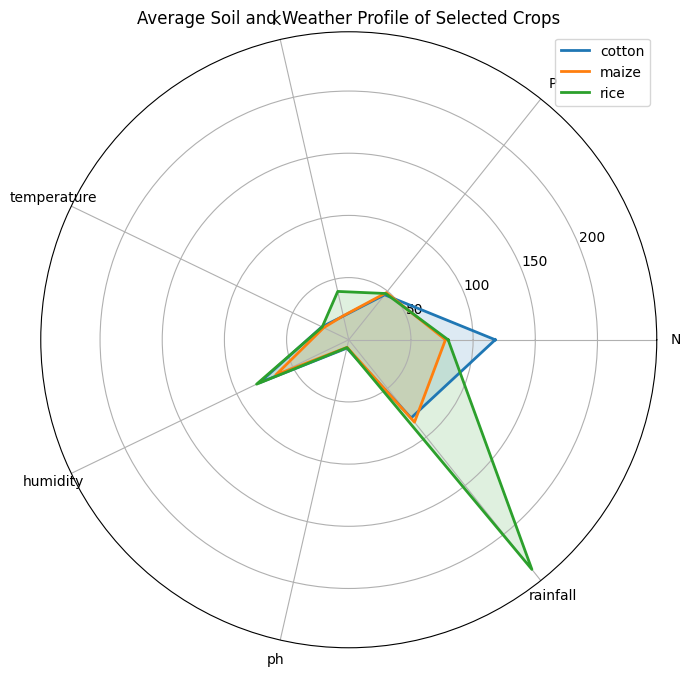

In [22]:
# Radar Chart for Selected Crops
from math import pi

selected = ["rice", "maize", "cotton"]

radar = df[df["label"].isin(selected)]

radar = radar.groupby("label")[feature_columns].mean()

categories = feature_columns
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(8,8))

ax = plt.subplot(111, polar=True)

for crop in radar.index:

    values = radar.loc[crop].tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=2, label=crop)
    ax.fill(angles, values, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

plt.title("Average Soil and Weather Profile of Selected Crops")

plt.legend()

plt.show()

In [23]:
#Feature Engineering
# Create a Working Copy

df_fe = df.copy()

print("Feature Engineering Dataset Shape:", df_fe.shape)

Feature Engineering Dataset Shape: (2200, 9)


In [24]:
# Total Nutrient Content

df_fe["Total_Nutrients"] = (
    df_fe["N"] +
    df_fe["P"] +
    df_fe["K"]
)

df_fe[["N","P","K","Total_Nutrients"]].head()

,N,P,K,Total_Nutrients
0,90,42,43,175
1,85,58,41,184
2,60,55,44,159
3,74,35,40,149
4,78,42,42,162


In [25]:
# Nutrient Balance
df_fe["NPK_Balance"] = (
    df_fe["N"] /
    (df_fe["P"] + df_fe["K"] + 1)
)

df_fe["NPK_Balance"].describe()

,NPK_Balance
count,2200.000000
mean,0.669445
std,0.568198
min,0.000000
25%,0.214964
50%,0.484612
75%,1.011439
max,2.725490


In [26]:
# Mean Nutrient Content

df_fe["Average_Nutrient"] = (
    df_fe["N"] +
    df_fe["P"] +
    df_fe["K"]
) / 3

df_fe["Average_Nutrient"].head()

,Average_Nutrient
0,58.333333
1,61.333333
2,53.000000
3,49.666667
4,54.000000


In [27]:
# Temperature-Humidity Index

df_fe["Temp_Humidity_Index"] = (
    df_fe["temperature"] *
    df_fe["humidity"]
)

df_fe["Temp_Humidity_Index"].head()

,Temp_Humidity_Index
0,1712.196283
1,1748.595734
2,1893.744627
3,2123.482908
4,1642.720357


In [28]:
# Soil Moisture Indicator

df_fe["Moisture_Index"] = (
    df_fe["humidity"] *
    df_fe["rainfall"]
)

df_fe["Moisture_Index"].head()

,Moisture_Index
0,16641.270870
1,18204.892093
2,21729.738241
3,19467.583326
4,21439.015172


In [29]:
# Soil Acidity Interaction
df_fe["PH_Rainfall"] = (
    df_fe["ph"] *
    df_fe["rainfall"]
)

df_fe["PH_Rainfall"].head()

,PH_Rainfall
0,1319.686807
1,1595.223513
2,2069.534380
3,1695.288324
4,2004.132110


In [30]:
# Growing Condition Score

df_fe["Growing_Score"] = (
    df_fe["temperature"] +
    df_fe["humidity"] +
    df_fe["rainfall"]
)

df_fe["Growing_Score"].head()

,Growing_Score
0,305.818024
1,328.745643
2,369.289470
3,349.513493
4,364.452388


In [31]:
# Engineered Features

new_features = [

    "Total_Nutrients",

    "NPK_Balance",

    "Average_Nutrient",

    "Temp_Humidity_Index",

    "Moisture_Index",

    "PH_Rainfall",

    "Growing_Score"

]

df_fe[new_features].head()

,Total_Nutrients,NPK_Balance,Average_Nutrient,Temp_Humidity_Index,Moisture_Index,PH_Rainfall,Growing_Score
0,175,1.046512,58.333333,1712.196283,16641.270870,1319.686807,305.818024
1,184,0.850000,61.333333,1748.595734,18204.892093,1595.223513,328.745643
2,159,0.600000,53.000000,1893.744627,21729.738241,2069.534380,369.289470
3,149,0.973684,49.666667,2123.482908,19467.583326,1695.288324,349.513493
4,162,0.917647,54.000000,1642.720357,21439.015172,2004.132110,364.452388


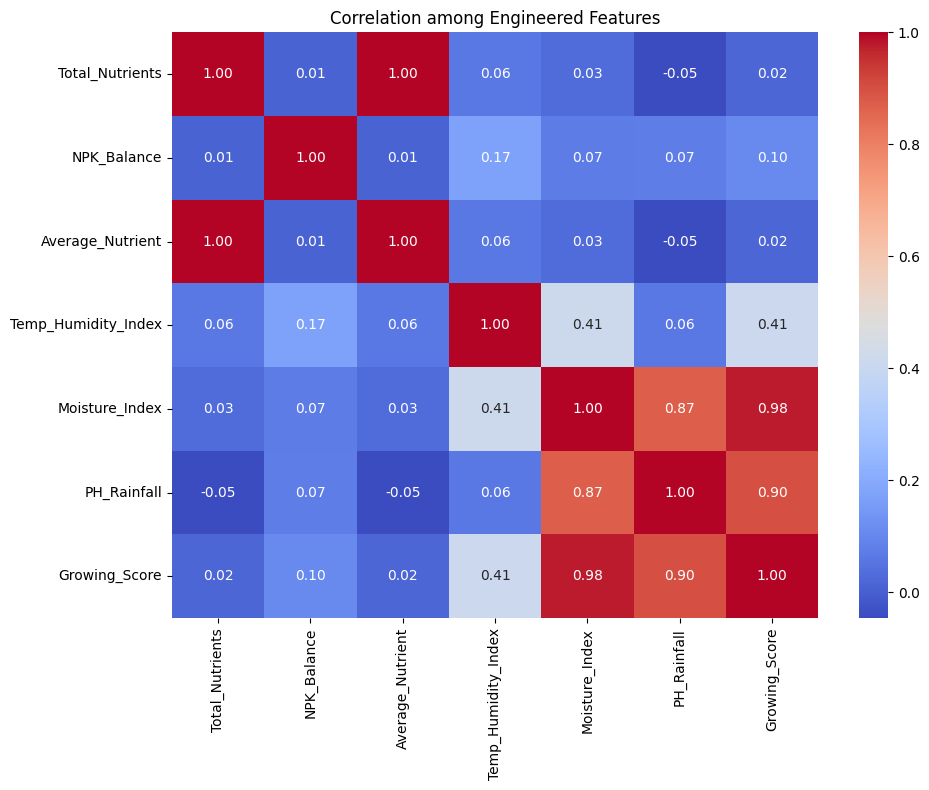

In [32]:
# Correlation of Engineered Features

plt.figure(figsize=(10,8))

sns.heatmap(

    df_fe[new_features].corr(),

    annot=True,

    fmt=".2f",

    cmap="coolwarm"

)

plt.title("Correlation among Engineered Features")

plt.tight_layout()

plt.show()

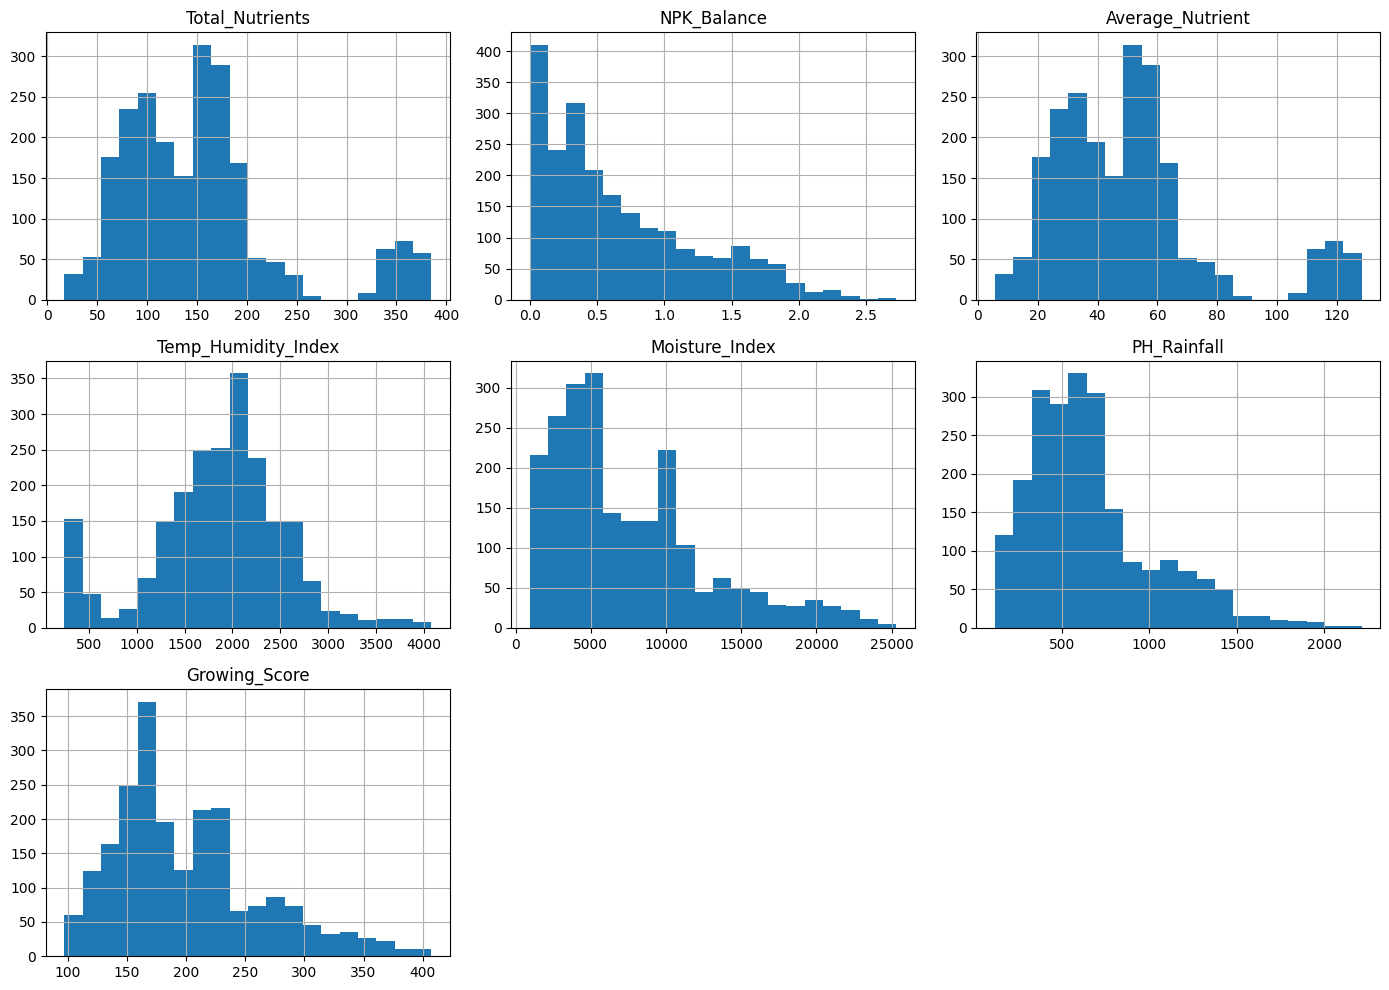

In [33]:
# Distribution of New Features

df_fe[new_features].hist(

    bins=20,

    figsize=(14,10)

)

plt.tight_layout()

plt.show()

In [34]:
# Updated Dataset

print(df_fe.shape)

df_fe.head()

(2200, 16)


,N,P,K,temperature,humidity,ph,rainfall,label,label_encoded,Total_Nutrients,NPK_Balance,Average_Nutrient,Temp_Humidity_Index,Moisture_Index,PH_Rainfall,Growing_Score
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,20,175,1.046512,58.333333,1712.196283,16641.270870,1319.686807,305.818024
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,20,184,0.850000,61.333333,1748.595734,18204.892093,1595.223513,328.745643
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,20,159,0.600000,53.000000,1893.744627,21729.738241,2069.534380,369.289470
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,20,149,0.973684,49.666667,2123.482908,19467.583326,1695.288324,349.513493
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,20,162,0.917647,54.000000,1642.720357,21439.015172,2004.132110,364.452388


In [35]:
# Save Dataset

df_fe.to_csv(
    "Crop_Recommendation_Feature_Engineered.csv",
    index=False
)

print("Feature engineered dataset saved successfully.")

Feature engineered dataset saved successfully.


In [36]:
# Define Predictor Variables and Target Variable

X = df_fe.drop(columns=["label", "label_encoded"])
y = df_fe["label"]

print("Predictor Shape:", X.shape)
print("Target Shape:", y.shape)

Predictor Shape: (2200, 14)
Target Shape: (2200,)


In [37]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (1760, 14)
Testing Set  : (440, 14)


In [38]:
# Verify Stratified Split

print("Training Distribution")
print(y_train.value_counts().sort_index())

print("\nTesting Distribution")
print(y_test.value_counts().sort_index())

Training Distribution
label
apple          80
banana         80
blackgram      80
chickpea       80
coconut        80
coffee         80
cotton         80
grapes         80
jute           80
kidneybeans    80
lentil         80
maize          80
mango          80
mothbeans      80
mungbean       80
muskmelon      80
orange         80
papaya         80
pigeonpeas     80
pomegranate    80
rice           80
watermelon     80
Name: count, dtype: int64

Testing Distribution
label
apple          20
banana         20
blackgram      20
chickpea       20
coconut        20
coffee         20
cotton         20
grapes         20
jute           20
kidneybeans    20
lentil         20
maize          20
mango          20
mothbeans      20
mungbean       20
muskmelon      20
orange         20
papaya         20
pigeonpeas     20
pomegranate    20
rice           20
watermelon     20
Name: count, dtype: int64


In [39]:
# Standard Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [40]:
# Convert to DataFrame

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled.head()

,N,P,K,temperature,humidity,ph,rainfall,Total_Nutrients,NPK_Balance,Average_Nutrient,Temp_Humidity_Index,Moisture_Index,PH_Rainfall,Growing_Score
1607,-1.371628,-1.072910,-0.673510,0.819481,0.924395,0.937545,0.199440,-1.499135,-1.182692,-1.499135,1.263240,0.591107,0.444856,0.579015
1212,-1.127411,2.084513,3.015261,0.783251,0.426613,-1.153846,-0.643677,2.247744,-1.133523,2.247744,0.772089,-0.390177,-0.797572,-0.355133
362,-1.073140,0.536162,-0.476250,-0.879968,-2.186291,-1.107452,0.694001,-0.574905,-0.979871,-0.574905,-1.952700,-0.838000,0.359025,-0.243390
566,-0.340487,-0.465713,-0.594606,0.138043,-0.459237,-0.229482,-1.231744,-0.724780,-0.002644,-0.724780,-0.344523,-1.039471,-1.227603,-1.252240
1671,-0.883193,-1.255069,-0.791866,-2.563232,0.915842,-0.341959,0.289941,-1.424197,0.334512,-1.424197,-0.990602,0.676155,0.211302,0.378068


In [41]:
# Check Mean and Standard Deviation

summary = pd.DataFrame({

    "Mean": X_train_scaled.mean(),

    "Standard Deviation": X_train_scaled.std()

})

summary.round(3)

,Mean,Standard Deviation
N,0.0,1.0
P,0.0,1.0
K,0.0,1.0
temperature,-0.0,1.0
humidity,-0.0,1.0
ph,-0.0,1.0
rainfall,0.0,1.0
Total_Nutrients,-0.0,1.0
NPK_Balance,0.0,1.0
Average_Nutrient,0.0,1.0


In [42]:
# Compare Original and Scaled Data

comparison = pd.DataFrame({

    "Original Mean": X_train.mean(),

    "Scaled Mean": X_train_scaled.mean(),

    "Original Std": X_train.std(),

    "Scaled Std": X_train_scaled.std()

})

comparison.round(3)

,Original Mean,Scaled Mean,Original Std,Scaled Std
N,50.548,0.0,36.863,1.0
P,53.340,0.0,32.948,1.0
K,48.143,0.0,50.709,1.0
temperature,25.609,-0.0,5.080,1.0
humidity,71.417,-0.0,22.281,1.0
ph,6.474,-0.0,0.783,1.0
rainfall,103.452,0.0,54.993,1.0
Total_Nutrients,152.031,-0.0,80.089,1.0
NPK_Balance,0.668,0.0,0.565,1.0
Average_Nutrient,50.677,0.0,26.696,1.0


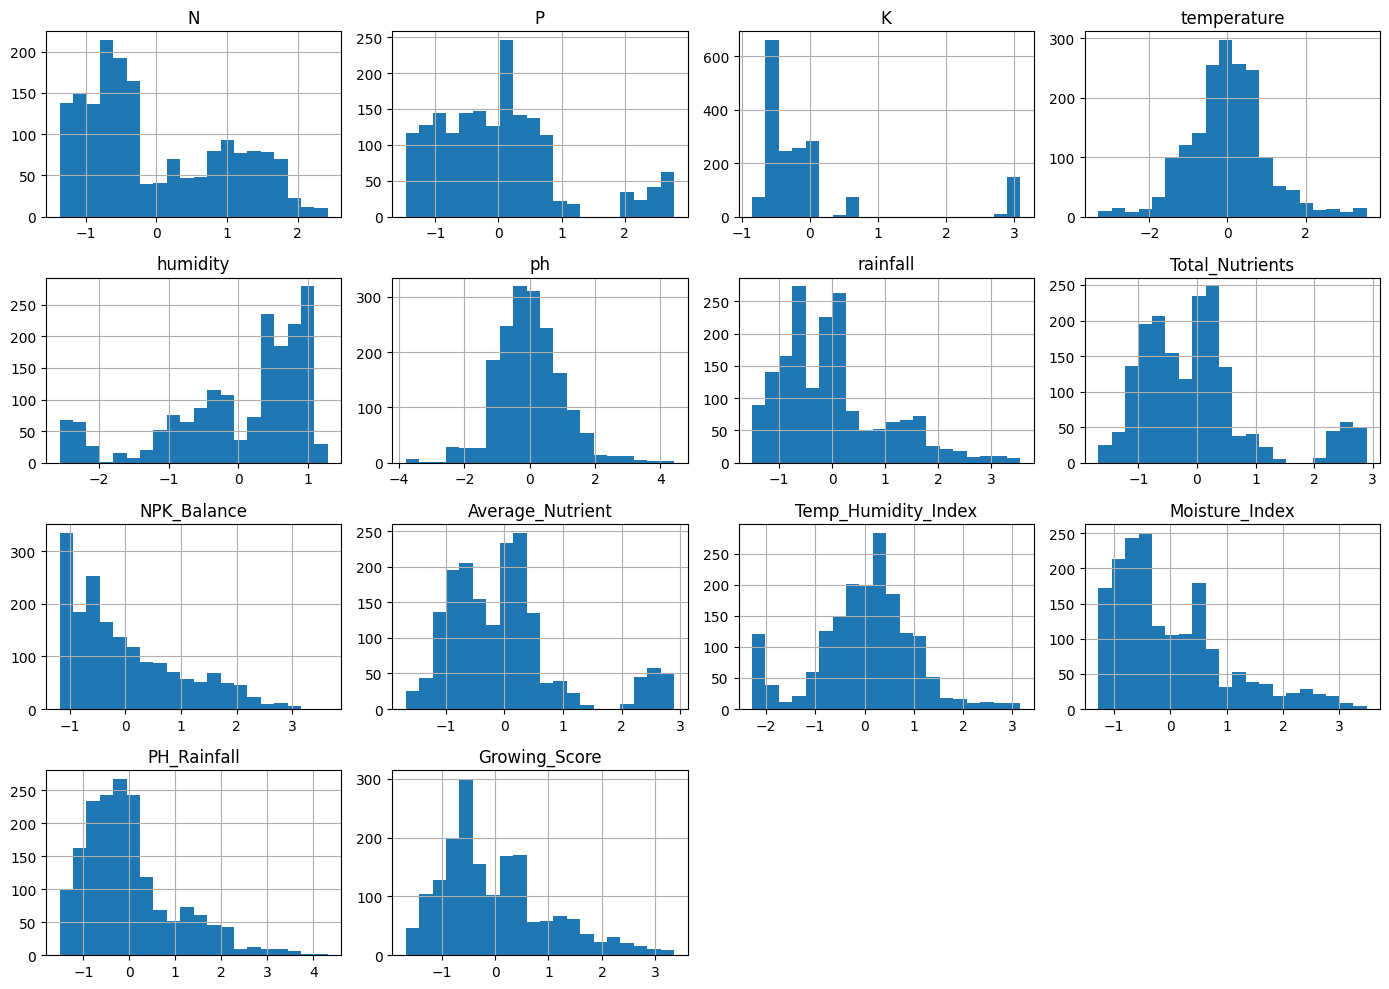

In [43]:
# Histogram After Scaling
X_train_scaled.hist(
    figsize=(14,10),
    bins=20
)

plt.tight_layout()
plt.show()

In [44]:
# Store Model Results

results = []

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [45]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state=42,
    max_iter=5000
)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, average="macro")
lr_recall = recall_score(y_test, lr_pred, average="macro")
lr_f1 = f1_score(y_test, lr_pred, average="macro")

results.append([
    "Logistic Regression",
    lr_accuracy,
    lr_precision,
    lr_recall,
    lr_f1
])

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Accuracy : 0.9795454545454545
Precision: 0.9807563695334593
Recall   : 0.9795454545454546
F1 Score : 0.9794077344520805


In [46]:
# Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
dt = DecisionTreeClassifier(
    random_state=42
)

# Train the model
dt.fit(X_train_scaled, y_train)

# Predict on testing data
dt_pred = dt.predict(X_test_scaled)

# Calculate evaluation metrics
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(
    y_test,
    dt_pred,
    average="macro"
)

dt_recall = recall_score(
    y_test,
    dt_pred,
    average="macro"
)

dt_f1 = f1_score(
    y_test,
    dt_pred,
    average="macro"
)

# Store model results
results.append([
    "Decision Tree",
    dt_accuracy,
    dt_precision,
    dt_recall,
    dt_f1
])

# Display results
print("Decision Tree Performance")
print("-" * 40)
print("Accuracy :", round(dt_accuracy,4))
print("Precision:", round(dt_precision,4))
print("Recall   :", round(dt_recall,4))
print("F1 Score :", round(dt_f1,4))

Decision Tree Performance
----------------------------------------
Accuracy : 0.9909
Precision: 0.9912
Recall   : 0.9909
F1 Score : 0.9909


<Figure size 1200x1000 with 0 Axes>

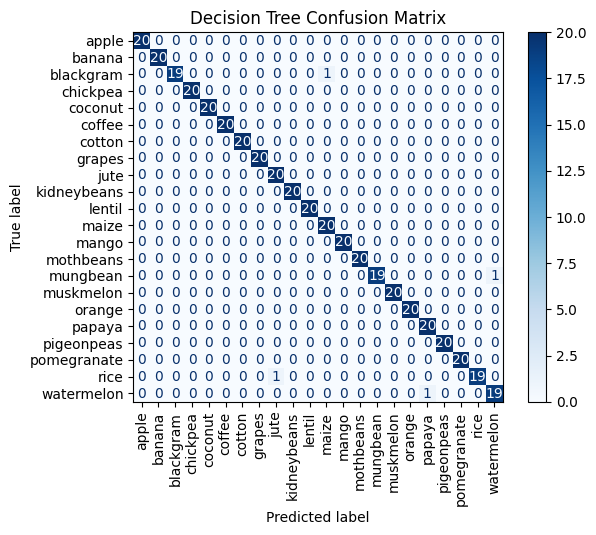

In [47]:
# Confusion Matrix

plt.figure(figsize=(12,10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred,
    xticks_rotation=90,
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")

plt.show()

In [48]:
# Classification Report

print("Decision Tree Classification Report")
print("-" * 50)

print(classification_report(
    y_test,
    dt_pred
))

Decision Tree Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      0.95      0.97        20
   muskmelon       1.00      1.00      1.00     

In [49]:
# 5-Fold Cross Validation


from sklearn.model_selection import cross_val_score

dt_cv = cross_val_score(
    dt,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores")
print(dt_cv)

print("\nAverage CV Accuracy :", round(dt_cv.mean(),4))
print("Standard Deviation  :", round(dt_cv.std(),4))

Cross Validation Scores
[0.98579545 0.97727273 0.98011364 0.98579545 0.98011364]

Average CV Accuracy : 0.9818
Standard Deviation  : 0.0034


In [50]:
# Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

# Train the model
rf.fit(X_train_scaled, y_train)

# Predict on testing data
rf_pred = rf.predict(X_test_scaled)

# Calculate evaluation metrics
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(
    y_test,
    rf_pred,
    average="macro"
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    average="macro"
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average="macro"
)

# Store model results
results.append([
    "Random Forest",
    rf_accuracy,
    rf_precision,
    rf_recall,
    rf_f1
])

# Display model performance
print("Random Forest Performance")
print("-" * 40)

print("Accuracy :", round(rf_accuracy,4))
print("Precision:", round(rf_precision,4))
print("Recall   :", round(rf_recall,4))
print("F1 Score :", round(rf_f1,4))

Random Forest Performance
----------------------------------------
Accuracy : 0.9955
Precision: 0.9957
Recall   : 0.9955
F1 Score : 0.9955


<Figure size 1200x1000 with 0 Axes>

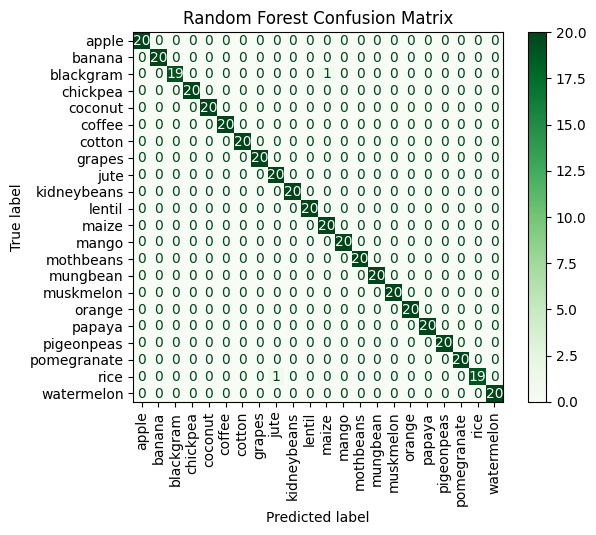

In [51]:
# Random Forest Confusion Matrix


plt.figure(figsize=(12,10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    xticks_rotation=90,
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

In [52]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                Feature  Importance
4              humidity    0.133506
2                     K    0.110414
6              rainfall    0.099666
1                     P    0.087408
11       Moisture_Index    0.085761
13        Growing_Score    0.084615
7       Total_Nutrients    0.072220
10  Temp_Humidity_Index    0.066201
12          PH_Rainfall    0.064257
9      Average_Nutrient    0.061858
0                     N    0.059445
8           NPK_Balance    0.035942
3           temperature    0.021014
5                    ph    0.017692


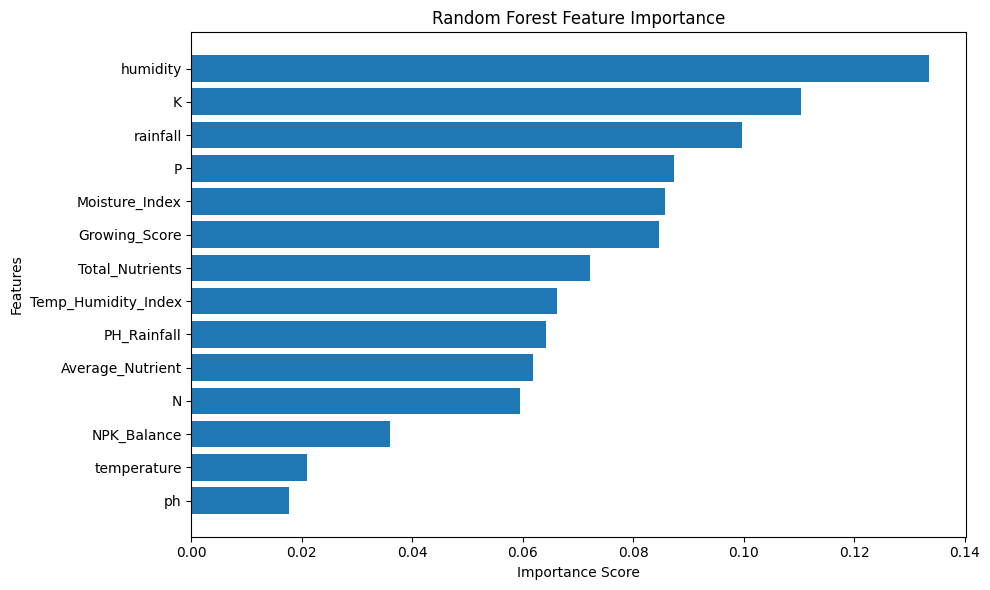

In [53]:
# Feature Importance Plot

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [54]:
# 5-Fold Cross Validation

rf_cv = cross_val_score(
    rf,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores")
print(rf_cv)

print("\nAverage CV Accuracy :", round(rf_cv.mean(),4))

print("Standard Deviation  :", round(rf_cv.std(),4))

Cross Validation Scores
[0.99147727 0.98863636 1.         1.         0.98295455]

Average CV Accuracy : 0.9926
Standard Deviation  : 0.0066


In [55]:
# K-Nearest Neighbours (KNN) Classifier

from sklearn.neighbors import KNeighborsClassifier

# Create KNN model
knn = KNeighborsClassifier(
    n_neighbors=5
)

# Train the model
knn.fit(X_train_scaled, y_train)

# Predict on testing data
knn_pred = knn.predict(X_test_scaled)

# Calculate evaluation metrics
knn_accuracy = accuracy_score(y_test, knn_pred)

knn_precision = precision_score(
    y_test,
    knn_pred,
    average="macro"
)

knn_recall = recall_score(
    y_test,
    knn_pred,
    average="macro"
)

knn_f1 = f1_score(
    y_test,
    knn_pred,
    average="macro"
)

# Store model results
results.append([
    "K-Nearest Neighbours",
    knn_accuracy,
    knn_precision,
    knn_recall,
    knn_f1
])

# Display model performance
print("K-Nearest Neighbours Performance")
print("-" * 40)

print("Accuracy :", round(knn_accuracy, 4))
print("Precision:", round(knn_precision, 4))
print("Recall   :", round(knn_recall, 4))
print("F1 Score :", round(knn_f1, 4))

K-Nearest Neighbours Performance
----------------------------------------
Accuracy : 0.9795
Precision: 0.9815
Recall   : 0.9795
F1 Score : 0.9793


<Figure size 1200x1000 with 0 Axes>

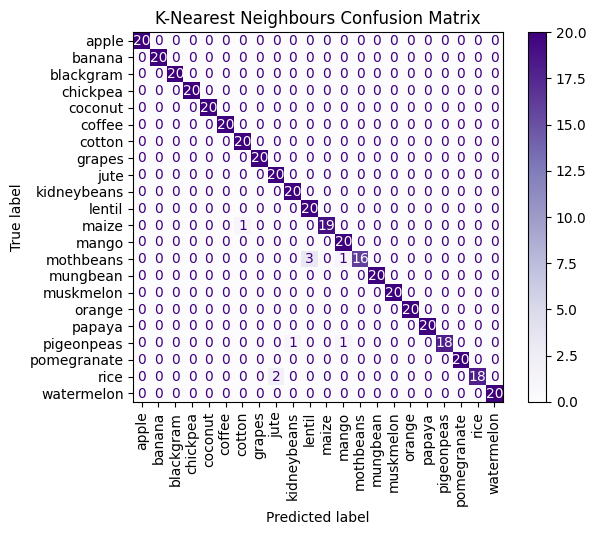

In [56]:
# KNN Confusion Matrix

plt.figure(figsize=(12,10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_pred,
    xticks_rotation=90,
    cmap="Purples"
)

plt.title("K-Nearest Neighbours Confusion Matrix")

plt.show()

In [57]:
# KNN Classification Report

print("K-Nearest Neighbours Classification Report")
print("-" * 50)

print(classification_report(
    y_test,
    knn_pred
))

K-Nearest Neighbours Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.87      1.00      0.93        20
       maize       1.00      0.95      0.97        20
       mango       0.91      1.00      0.95        20
   mothbeans       1.00      0.80      0.89        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.

In [58]:
# 5-Fold Cross Validation

knn_cv = cross_val_score(
    knn,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores")
print(knn_cv)

print("\nAverage CV Accuracy :", round(knn_cv.mean(), 4))
print("Standard Deviation  :", round(knn_cv.std(), 4))

Cross Validation Scores
[0.96590909 0.96590909 0.98295455 0.97727273 0.96590909]

Average CV Accuracy : 0.9716
Standard Deviation  : 0.0072


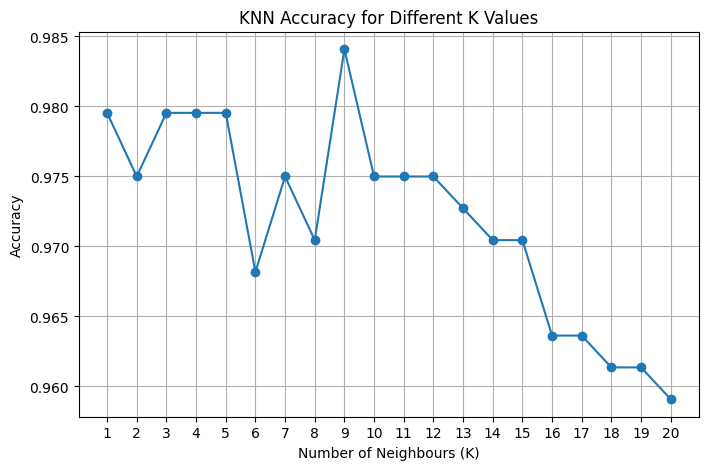

Best K : 9
Best Accuracy : 0.9841


In [59]:
# Finding the Best Value of K

k_values = range(1, 21)

accuracy_scores = []

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train_scaled, y_train)

    prediction = model.predict(X_test_scaled)

    accuracy_scores.append(
        accuracy_score(y_test, prediction)
    )

plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    accuracy_scores,
    marker="o"
)

plt.title("KNN Accuracy for Different K Values")

plt.xlabel("Number of Neighbours (K)")

plt.ylabel("Accuracy")

plt.xticks(k_values)

plt.grid(True)

plt.show()

best_k = k_values[np.argmax(accuracy_scores)]

print("Best K :", best_k)

print("Best Accuracy :", round(max(accuracy_scores),4))

In [60]:
# Gaussian Naive Bayes Classifier

from sklearn.naive_bayes import GaussianNB

# Create Gaussian Naive Bayes model
nb = GaussianNB()

# Train the model
nb.fit(X_train_scaled, y_train)

# Predict on testing data
nb_pred = nb.predict(X_test_scaled)

# Calculate evaluation metrics
nb_accuracy = accuracy_score(y_test, nb_pred)

nb_precision = precision_score(
    y_test,
    nb_pred,
    average="macro"
)

nb_recall = recall_score(
    y_test,
    nb_pred,
    average="macro"
)

nb_f1 = f1_score(
    y_test,
    nb_pred,
    average="macro"
)

# Store model results
results.append([
    "Gaussian Naive Bayes",
    nb_accuracy,
    nb_precision,
    nb_recall,
    nb_f1
])

# Display model performance
print("Gaussian Naive Bayes Performance")
print("-" * 40)

print("Accuracy :", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("F1 Score :", round(nb_f1, 4))

Gaussian Naive Bayes Performance
----------------------------------------
Accuracy : 0.9909
Precision: 0.9917
Recall   : 0.9909
F1 Score : 0.9909


<Figure size 1200x1000 with 0 Axes>

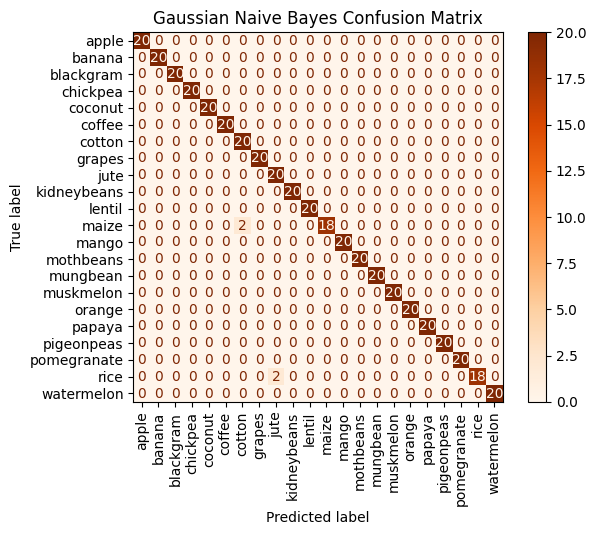

In [61]:

# Gaussian Naive Bayes Confusion Matrix

plt.figure(figsize=(12,10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    nb_pred,
    xticks_rotation=90,
    cmap="Oranges"
)

plt.title("Gaussian Naive Bayes Confusion Matrix")

plt.show()

In [62]:
# Gaussian Naive Bayes Classification Report

print("Gaussian Naive Bayes Classification Report")
print("-" * 50)

print(classification_report(
    y_test,
    nb_pred
))

Gaussian Naive Bayes Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.91      1.00      0.95        20
      grapes       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      0.90      0.95        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.

In [63]:
# 5-Fold Cross Validation

nb_cv = cross_val_score(
    nb,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores")
print(nb_cv)

print("\nAverage CV Accuracy :", round(nb_cv.mean(), 4))

print("Standard Deviation  :", round(nb_cv.std(), 4))

Cross Validation Scores
[0.98579545 0.99147727 1.         0.99431818 0.98295455]

Average CV Accuracy : 0.9909
Standard Deviation  : 0.0061


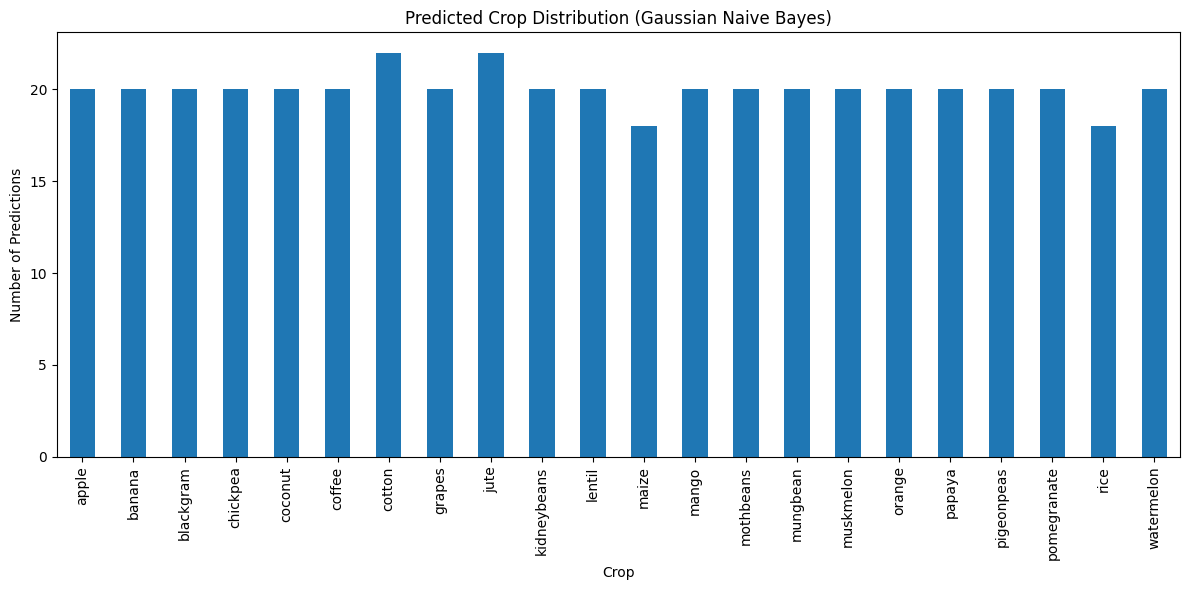

In [64]:
# Prediction Distribution

prediction_counts = pd.Series(nb_pred).value_counts().sort_index()

plt.figure(figsize=(12,6))

prediction_counts.plot(
    kind="bar"
)

plt.title("Predicted Crop Distribution (Gaussian Naive Bayes)")

plt.xlabel("Crop")

plt.ylabel("Number of Predictions")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [65]:
# Model Comparison

# Create Results DataFrame
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

# Round values for better readability
results_df.iloc[:,1:] = results_df.iloc[:,1:].round(4)

# Display comparison table
print("Model Performance Comparison")
print("-" * 70)

print(results_df)

Model Performance Comparison
----------------------------------------------------------------------
                  Model  Accuracy  Precision  Recall  F1 Score
0   Logistic Regression    0.9795     0.9808  0.9795    0.9794
1         Decision Tree    0.9909     0.9912  0.9909    0.9909
2         Random Forest    0.9955     0.9957  0.9955    0.9955
3  K-Nearest Neighbours    0.9795     0.9815  0.9795    0.9793
4  Gaussian Naive Bayes    0.9909     0.9917  0.9909    0.9909


In [66]:
# Rank Models by Accuracy


results_sorted = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("Models Ranked by Accuracy")
print("-" * 70)

print(results_sorted)

Models Ranked by Accuracy
----------------------------------------------------------------------
                  Model  Accuracy  Precision  Recall  F1 Score
0         Random Forest    0.9955     0.9957  0.9955    0.9955
1  Gaussian Naive Bayes    0.9909     0.9917  0.9909    0.9909
2         Decision Tree    0.9909     0.9912  0.9909    0.9909
3   Logistic Regression    0.9795     0.9808  0.9795    0.9794
4  K-Nearest Neighbours    0.9795     0.9815  0.9795    0.9793


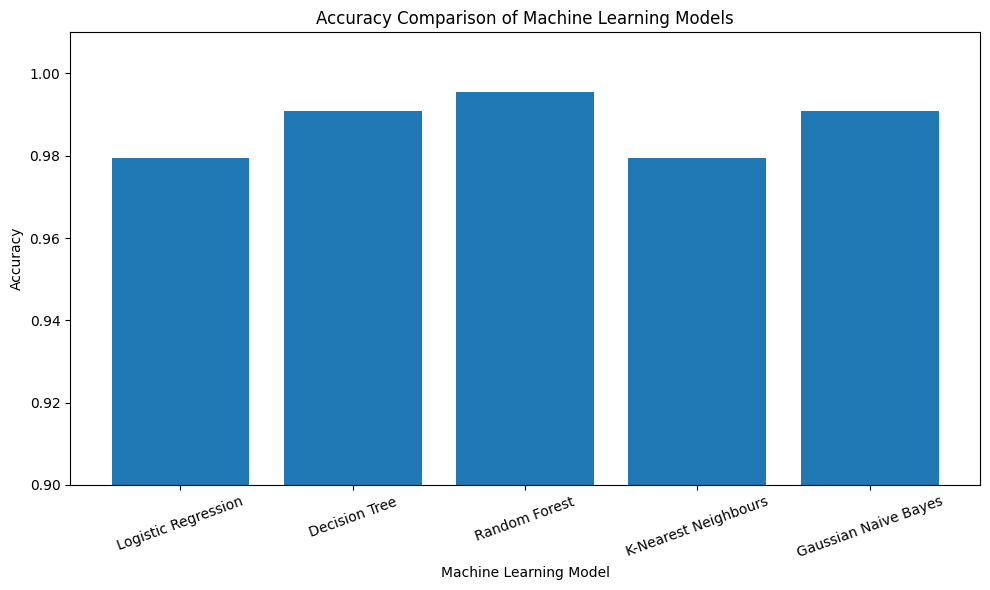

In [67]:
# Accuracy Comparison

plt.figure(figsize=(10,6))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title("Accuracy Comparison of Machine Learning Models")

plt.xlabel("Machine Learning Model")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.ylim(0.90,1.01)

plt.tight_layout()

plt.show()

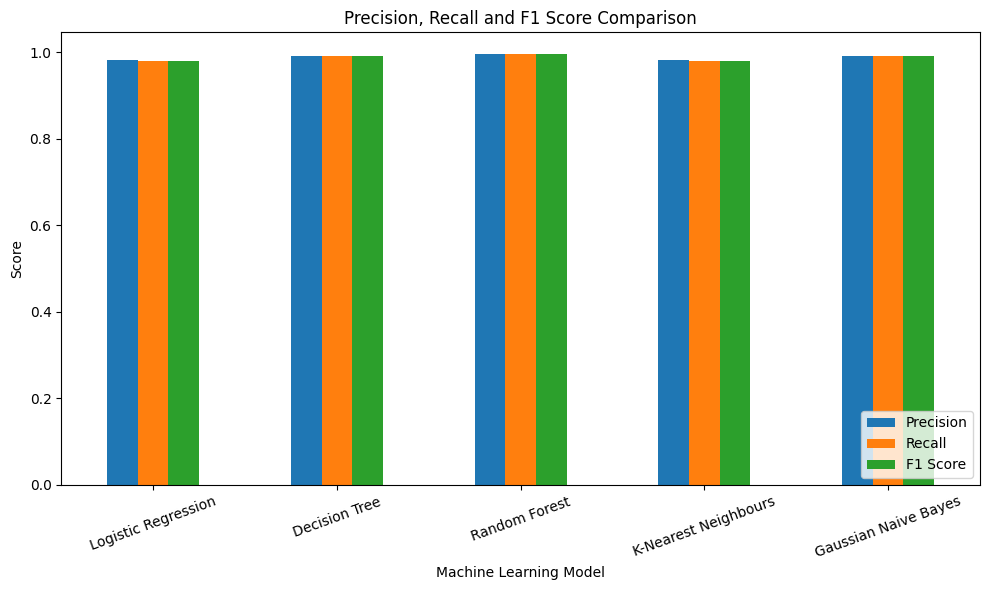

In [68]:
# Precision, Recall and F1 Comparison

metric_df = results_df.set_index("Model")

metric_df[
    [
        "Precision",
        "Recall",
        "F1 Score"
    ]
].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Precision, Recall and F1 Score Comparison")

plt.xlabel("Machine Learning Model")

plt.ylabel("Score")

plt.xticks(rotation=20)

plt.legend(loc="lower right")

plt.tight_layout()

plt.show()

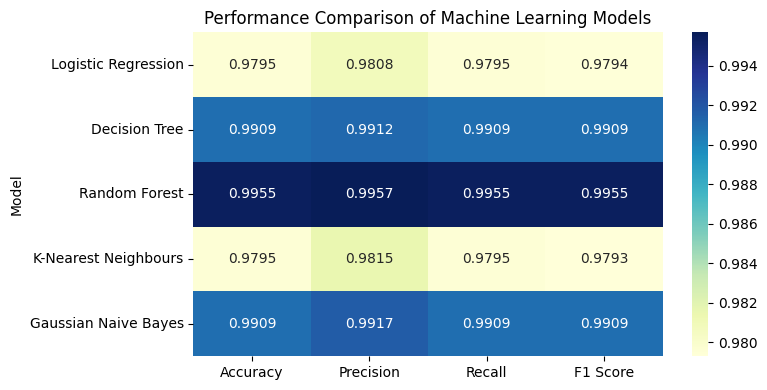

In [69]:
# Performance Heatmap

plt.figure(figsize=(8,4))

sns.heatmap(
    results_df.set_index("Model"),
    annot=True,
    cmap="YlGnBu",
    fmt=".4f"
)

plt.title("Performance Comparison of Machine Learning Models")

plt.tight_layout()

plt.show()

In [70]:
# Identify the Best Performing Model

best_model = results_df.loc[
    results_df["Accuracy"].idxmax()
]

print("Best Performing Model")
print("-" * 40)

print("Model      :", best_model["Model"])
print("Accuracy   :", round(best_model["Accuracy"],4))
print("Precision  :", round(best_model["Precision"],4))
print("Recall     :", round(best_model["Recall"],4))
print("F1 Score   :", round(best_model["F1 Score"],4))

Best Performing Model
----------------------------------------
Model      : Random Forest
Accuracy   : 0.9955
Precision  : 0.9957
Recall     : 0.9955
F1 Score   : 0.9955


In [71]:
# Summary Statistics

print("Summary Statistics")
print("-" * 40)

print(results_df.describe())

Summary Statistics
----------------------------------------
       Accuracy  Precision    Recall  F1 Score
count  5.000000   5.000000  5.000000  5.000000
mean   0.987260   0.988180  0.987260  0.987200
std    0.007329   0.006655  0.007329  0.007408
min    0.979500   0.980800  0.979500  0.979300
25%    0.979500   0.981500  0.979500  0.979400
50%    0.990900   0.991200  0.990900  0.990900
75%    0.990900   0.991700  0.990900  0.990900
max    0.995500   0.995700  0.995500  0.995500


In [72]:
# Decision Tree Hyperparameter Tuning

dt_parameters = {

    "criterion": ["gini", "entropy"],

    "max_depth": [None, 10, 20, 30],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4]
}

dt_grid = GridSearchCV(

    estimator=DecisionTreeClassifier(random_state=42),

    param_grid=dt_parameters,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

dt_grid.fit(X_train_scaled, y_train)

best_dt = dt_grid.best_estimator_

print("Best Decision Tree Parameters")
print(dt_grid.best_params_)

print("\nBest Cross Validation Accuracy")

print(round(dt_grid.best_score_,4))

Best Decision Tree Parameters
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}

Best Cross Validation Accuracy
0.9824


In [73]:
# Evaluate Tuned Decision Tree

dt_best_pred = best_dt.predict(X_test_scaled)

dt_best_accuracy = accuracy_score(
    y_test,
    dt_best_pred
)

dt_best_precision = precision_score(
    y_test,
    dt_best_pred,
    average="macro"
)

dt_best_recall = recall_score(
    y_test,
    dt_best_pred,
    average="macro"
)

dt_best_f1 = f1_score(
    y_test,
    dt_best_pred,
    average="macro"
)

print("Decision Tree After Hyperparameter Tuning")
print("-"*45)

print("Accuracy :", round(dt_best_accuracy,4))
print("Precision:", round(dt_best_precision,4))
print("Recall   :", round(dt_best_recall,4))
print("F1 Score :", round(dt_best_f1,4))

Decision Tree After Hyperparameter Tuning
---------------------------------------------
Accuracy : 0.9909
Precision: 0.9912
Recall   : 0.9909
F1 Score : 0.9909


In [74]:
# Random Forest Hyperparameter Tuning

rf_parameters = {

    "n_estimators": [100, 200],

    "max_depth": [None, 10, 20],

    "min_samples_split": [2, 5],

    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(

    estimator=RandomForestClassifier(
        random_state=42
    ),

    param_grid=rf_parameters,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

rf_grid.fit(X_train_scaled, y_train)

best_rf = rf_grid.best_estimator_

print("Best Random Forest Parameters")
print(rf_grid.best_params_)

print("\nBest Cross Validation Accuracy")

print(round(rf_grid.best_score_,4))

Best Random Forest Parameters
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross Validation Accuracy
0.9932


In [75]:
# Evaluate Tuned Random Forest

rf_best_pred = best_rf.predict(X_test_scaled)

rf_best_accuracy = accuracy_score(
    y_test,
    rf_best_pred
)

rf_best_precision = precision_score(
    y_test,
    rf_best_pred,
    average="macro"
)

rf_best_recall = recall_score(
    y_test,
    rf_best_pred,
    average="macro"
)

rf_best_f1 = f1_score(
    y_test,
    rf_best_pred,
    average="macro"
)

print("Random Forest After Hyperparameter Tuning")
print("-"*45)

print("Accuracy :", round(rf_best_accuracy,4))
print("Precision:", round(rf_best_precision,4))
print("Recall   :", round(rf_best_recall,4))
print("F1 Score :", round(rf_best_f1,4))

Random Forest After Hyperparameter Tuning
---------------------------------------------
Accuracy : 0.9955
Precision: 0.9957
Recall   : 0.9955
F1 Score : 0.9955


In [76]:
# KNN Hyperparameter Tuning

knn_parameters = {

    "n_neighbors": [3, 5, 7, 9],

    "weights": ["uniform", "distance"],

    "metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(

    estimator=KNeighborsClassifier(),

    param_grid=knn_parameters,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

knn_grid.fit(X_train_scaled, y_train)

best_knn = knn_grid.best_estimator_

print("Best KNN Parameters")
print(knn_grid.best_params_)

print("\nBest Cross Validation Accuracy")

print(round(knn_grid.best_score_,4))

Best KNN Parameters
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}

Best Cross Validation Accuracy
0.9812


In [77]:
# Evaluate Tuned KNN

knn_best_pred = best_knn.predict(X_test_scaled)

knn_best_accuracy = accuracy_score(
    y_test,
    knn_best_pred
)

knn_best_precision = precision_score(
    y_test,
    knn_best_pred,
    average="macro"
)

knn_best_recall = recall_score(
    y_test,
    knn_best_pred,
    average="macro"
)

knn_best_f1 = f1_score(
    y_test,
    knn_best_pred,
    average="macro"
)

print("KNN After Hyperparameter Tuning")
print("-"*45)

print("Accuracy :", round(knn_best_accuracy,4))
print("Precision:", round(knn_best_precision,4))
print("Recall   :", round(knn_best_recall,4))
print("F1 Score :", round(knn_best_f1,4))

KNN After Hyperparameter Tuning
---------------------------------------------
Accuracy : 0.9841
Precision: 0.9843
Recall   : 0.9841
F1 Score : 0.984


In [78]:
# Performance Comparison of Tuned Models

tuned_results = pd.DataFrame({

    "Model": [
        "Decision Tree",
        "Random Forest",
        "K-Nearest Neighbours"
    ],

    "Accuracy": [
        dt_best_accuracy,
        rf_best_accuracy,
        knn_best_accuracy
    ],

    "Precision": [
        dt_best_precision,
        rf_best_precision,
        knn_best_precision
    ],

    "Recall": [
        dt_best_recall,
        rf_best_recall,
        knn_best_recall
    ],

    "F1 Score": [
        dt_best_f1,
        rf_best_f1,
        knn_best_f1
    ]

})

tuned_results.iloc[:,1:] = tuned_results.iloc[:,1:].round(4)

print("Performance of Tuned Models")
print("-"*70)

print(tuned_results)

Performance of Tuned Models
----------------------------------------------------------------------
                  Model  Accuracy  Precision  Recall  F1 Score
0         Decision Tree    0.9909     0.9912  0.9909    0.9909
1         Random Forest    0.9955     0.9957  0.9955    0.9955
2  K-Nearest Neighbours    0.9841     0.9843  0.9841    0.9840


In [79]:
# Original vs Tuned Accuracy Comparison

comparison = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest",
        "K-Nearest Neighbours"
    ],

    "Original Accuracy":[
        dt_accuracy,
        rf_accuracy,
        knn_accuracy
    ],

    "Tuned Accuracy":[
        dt_best_accuracy,
        rf_best_accuracy,
        knn_best_accuracy
    ]

})

comparison.iloc[:,1:] = comparison.iloc[:,1:].round(4)

print(comparison)

                  Model  Original Accuracy  Tuned Accuracy
0         Decision Tree             0.9909          0.9909
1         Random Forest             0.9955          0.9955
2  K-Nearest Neighbours             0.9795          0.9841


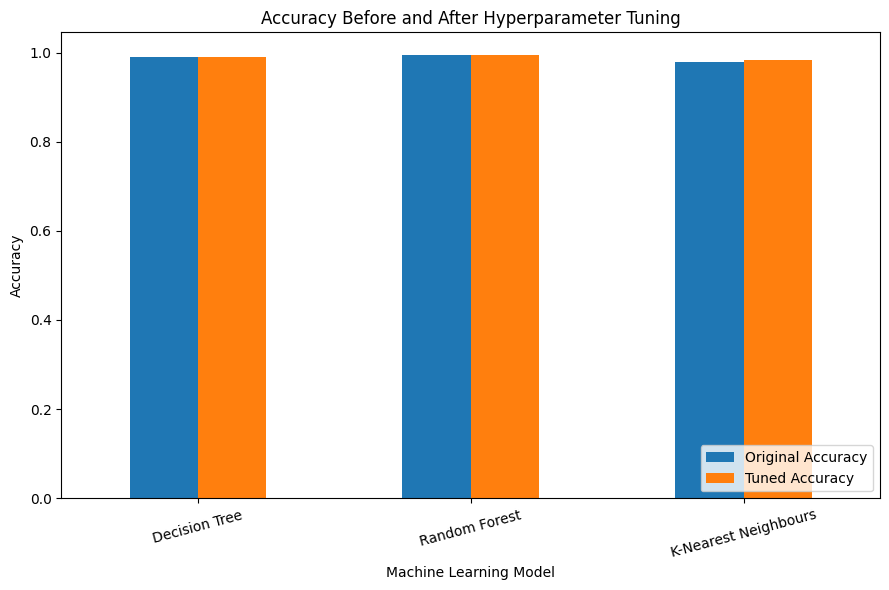

In [80]:
# Accuracy Improvement After Hyperparameter Tuning

comparison.set_index("Model").plot(

    kind="bar",

    figsize=(9,6)

)

plt.title("Accuracy Before and After Hyperparameter Tuning")

plt.xlabel("Machine Learning Model")

plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.legend(loc="lower right")

plt.tight_layout()

plt.show()

In [81]:
# Best Tuned Model

best_tuned = tuned_results.loc[
    tuned_results["Accuracy"].idxmax()
]

print("Best Tuned Model")
print("-"*40)

print("Model      :", best_tuned["Model"])
print("Accuracy   :", round(best_tuned["Accuracy"],4))
print("Precision  :", round(best_tuned["Precision"],4))
print("Recall     :", round(best_tuned["Recall"],4))
print("F1 Score   :", round(best_tuned["F1 Score"],4))

Best Tuned Model
----------------------------------------
Model      : Random Forest
Accuracy   : 0.9955
Precision  : 0.9957
Recall     : 0.9955
F1 Score   : 0.9955


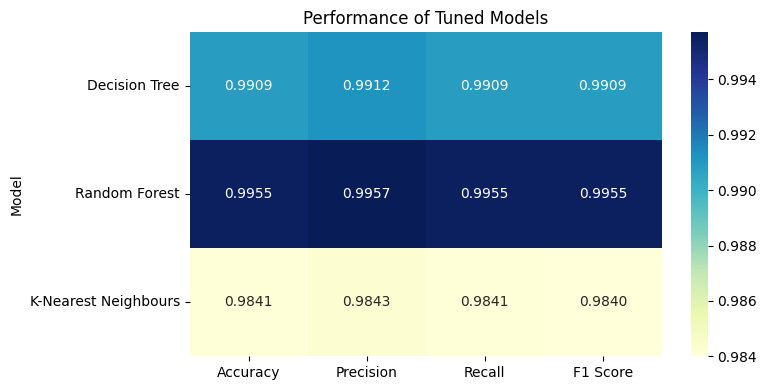

In [82]:
# Heatmap of Tuned Model Performance

plt.figure(figsize=(8,4))

sns.heatmap(

    tuned_results.set_index("Model"),

    annot=True,

    cmap="YlGnBu",

    fmt=".4f"

)

plt.title("Performance of Tuned Models")

plt.tight_layout()

plt.show()

In [83]:
# Select the Final Model

if best_tuned["Model"] == "Decision Tree":

    final_model = best_dt

elif best_tuned["Model"] == "Random Forest":

    final_model = best_rf

else:

    final_model = best_knn

print("Final Model Selected Successfully.")
print(type(final_model))

Final Model Selected Successfully.
<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [84]:
# Feature Importance using Random Forest

# Create a DataFrame containing feature importance scores

feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": best_rf.feature_importances_

})

# Sort features based on importance

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

).reset_index(drop=True)

print("Feature Importance")

print("-"*50)

print(feature_importance)

Feature Importance
--------------------------------------------------
                Feature  Importance
0              humidity    0.127673
1              rainfall    0.109411
2                     K    0.106634
3        Moisture_Index    0.084898
4                     P    0.084366
5         Growing_Score    0.078082
6       Total_Nutrients    0.073245
7      Average_Nutrient    0.068805
8   Temp_Humidity_Index    0.068242
9           PH_Rainfall    0.061248
10                    N    0.055699
11          NPK_Balance    0.038663
12          temperature    0.022734
13                   ph    0.020300


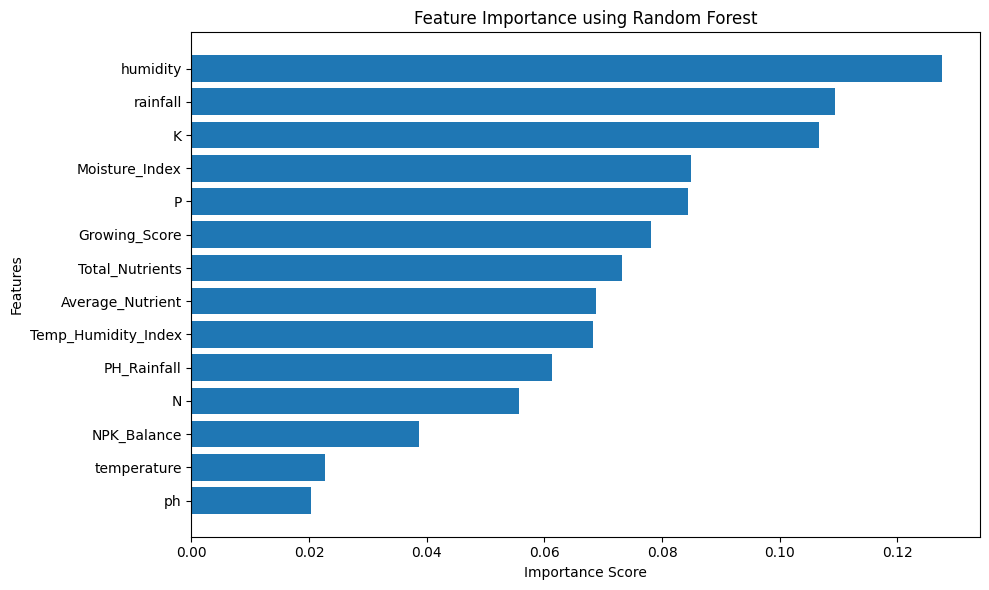

In [85]:
# Feature Importance Visualization

plt.figure(figsize=(10,6))

plt.barh(

    feature_importance["Feature"],

    feature_importance["Importance"]

)

plt.title("Feature Importance using Random Forest")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [86]:
# Permutation Feature Importance

from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(

    best_rf,

    X_test_scaled,

    y_test,

    scoring="accuracy",

    random_state=42,

    n_repeats=10

)

perm_df = pd.DataFrame({

    "Feature": X_test.columns,

    "Importance": perm_importance.importances_mean

})

perm_df = perm_df.sort_values(

    by="Importance",

    ascending=False

).reset_index(drop=True)

print("Permutation Feature Importance")

print("-"*50)

print(perm_df)

Permutation Feature Importance
--------------------------------------------------
                Feature  Importance
0              humidity    0.089318
1                     K    0.046364
2                     N    0.044773
3                     P    0.017500
4              rainfall    0.013864
5   Temp_Humidity_Index    0.012500
6        Moisture_Index    0.005000
7         Growing_Score    0.004545
8           PH_Rainfall    0.002273
9                    ph    0.002045
10          temperature    0.001591
11      Total_Nutrients    0.000682
12     Average_Nutrient    0.000682
13          NPK_Balance   -0.000455


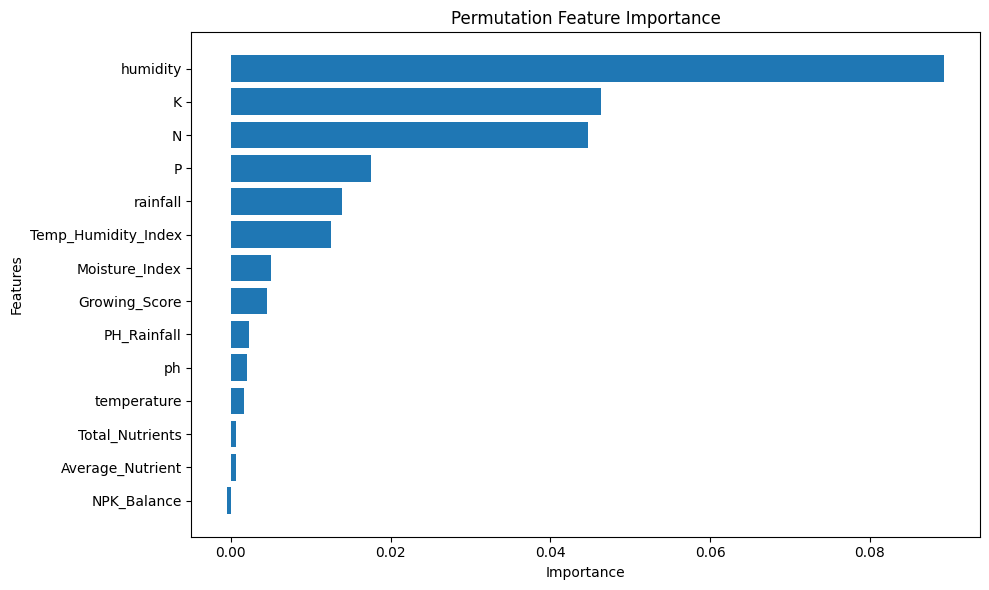

In [87]:
# Permutation Importance Plot

plt.figure(figsize=(10,6))

plt.barh(

    perm_df["Feature"],

    perm_df["Importance"]

)

plt.title("Permutation Feature Importance")

plt.xlabel("Importance")

plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [88]:
# Comparison of Feature Importance Methods

importance_comparison = feature_importance.merge(

    perm_df,

    on="Feature",

    suffixes=("_RandomForest", "_Permutation")

)

print("Comparison of Feature Importance Methods")

print("-"*60)

print(importance_comparison)

Comparison of Feature Importance Methods
------------------------------------------------------------
                Feature  Importance_RandomForest  Importance_Permutation
0              humidity                 0.127673                0.089318
1              rainfall                 0.109411                0.013864
2                     K                 0.106634                0.046364
3        Moisture_Index                 0.084898                0.005000
4                     P                 0.084366                0.017500
5         Growing_Score                 0.078082                0.004545
6       Total_Nutrients                 0.073245                0.000682
7      Average_Nutrient                 0.068805                0.000682
8   Temp_Humidity_Index                 0.068242                0.012500
9           PH_Rainfall                 0.061248                0.002273
10                    N                 0.055699                0.044773
11          NPK_Balanc

In [89]:
# Save the Final Machine Learning Model

import joblib

# Save the best performing model
joblib.dump(final_model, "crop_recommendation_model.pkl")

print("Machine Learning Model Saved Successfully.")

Machine Learning Model Saved Successfully.


In [90]:
# Save the Standard Scaler

joblib.dump(scaler, "standard_scaler.pkl")

print("Standard Scaler Saved Successfully.")

Standard Scaler Saved Successfully.


In [91]:
# Load Saved Model and Scaler

loaded_model = joblib.load("crop_recommendation_model.pkl")

loaded_scaler = joblib.load("standard_scaler.pkl")

print("Model Loaded Successfully.")

Model Loaded Successfully.


In [92]:
# Crop Recommendation Prediction

# Enter input values

N = float(input("Enter Nitrogen (N): "))
P = float(input("Enter Phosphorus (P): "))
K = float(input("Enter Potassium (K): "))
temperature = float(input("Enter Temperature (°C): "))
humidity = float(input("Enter Humidity (%): "))
ph = float(input("Enter pH Value: "))
rainfall = float(input("Enter Rainfall (mm): "))

Enter Nitrogen (N): 44
Enter Phosphorus (P): 34
Enter Potassium (K): 54
Enter Temperature (°C): 65
Enter Humidity (%): 65
Enter pH Value: 6
Enter Rainfall (mm): 54


In [93]:
# Feature Engineering for New Input

input_data = pd.DataFrame({

    "N":[N],
    "P":[P],
    "K":[K],
    "temperature":[temperature],
    "humidity":[humidity],
    "ph":[ph],
    "rainfall":[rainfall]

})

# Example engineered features
# Replace these with the exact engineered features you used

input_data["NPK_Sum"] = (
    input_data["N"] +
    input_data["P"] +
    input_data["K"]
)

In [94]:
# Remove NPK_Sum if it exists, as it was not used during scaler fitting
if "NPK_Sum" in input_data.columns:
    input_data = input_data.drop(columns=["NPK_Sum"])

# Re-engineer features for the single input instance to match the training data
input_data["Total_Nutrients"] = (
    input_data["N"] +
    input_data["P"] +
    input_data["K"]
)

input_data["NPK_Balance"] = (
    input_data["N"] /
    (input_data["P"] + input_data["K"] + 1)
)

input_data["Average_Nutrient"] = (
    input_data["N"] +
    input_data["P"] +
    input_data["K"]
) / 3

input_data["Temp_Humidity_Index"] = (
    input_data["temperature"] *
    input_data["humidity"]
)

input_data["Moisture_Index"] = (
    input_data["humidity"] *
    input_data["rainfall"]
)

input_data["PH_Rainfall"] = (
    input_data["ph"] *
    input_data["rainfall"]
)

input_data["Growing_Score"] = (
    input_data["temperature"] +
    input_data["humidity"] +

    input_data["rainfall"]
)

# Ensure the order of columns matches the order used during scaler fitting (X_train columns)
expected_feature_order = [
    'N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall',
    'Total_Nutrients', 'NPK_Balance', 'Average_Nutrient',
    'Temp_Humidity_Index', 'Moisture_Index', 'PH_Rainfall', 'Growing_Score'
]

input_data = input_data[expected_feature_order]

scaled_input = loaded_scaler.transform(input_data)

In [95]:
# Predict Recommended Crop

prediction = loaded_model.predict(scaled_input)

print()

print("="*50)

print("Recommended Crop")

print("="*50)

print(prediction[0])

print("="*50)


Recommended Crop
mango
